# Stage 1: Well Data Cleaning

*SPE Africa Geothermal Datathon submission*

This notebook takes the raw geothermal well data and turns it into a trustworthy, analysis-ready dataset. It does two main jobs: (1) it corrects the **depths**, because the wells are drilled at a slant so the depth measured along the borehole is deeper than the rock's true depth below ground, and (2) it **fills in missing porosity** (the rock's empty pore space) from density logs and then validates that fill against an independent public dataset. Getting these right matters: every later estimate of how much heat and power the reservoir can deliver rests on these cleaned numbers.

## Setup

We load the project's helper library and three datasets: the **raw** well data (as delivered, with quality flags), a **clean** version produced by our cleaning pipeline, and **ThermoGIS** — an independent, public regional dataset we use later as a sanity check.

In [2]:
from __future__ import annotations

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from geothermal import config
from geothermal.datasets import clean_reservoir_dataset
from geothermal.io import load_target_lithologies, load_thermogis
from geothermal.petrophysics import (
    density_porosity,
    imputed_vs_thermogis,
    porosity_cross_well_skill,
    porosity_log_quality,
)

FIG_DIR = config.OUTPUTS_DIR / "figures" / "phase1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

raw = load_target_lithologies()
clean = clean_reservoir_dataset(refresh=True)
thermogis = load_thermogis()

## Section 1: Fixing the depth (slanted holes)

Wells are rarely drilled straight down. The depth measured along a tilted borehole (**measured / along-hole depth**, AH) overstates how deep a rock layer truly sits below the surface (**true vertical depth**, TVD). The raw data had TVD missing on every row and flagged for review, so our pipeline reconstructs it. Look for the clean dataset reporting TVD filled on ~100% of rows, and each well's reservoir interval coming out *thinner* in true vertical terms than it looked along the slanted hole.

In [4]:
print("=" * 78)
print("SECTION 1 — DEPTH RECONCILIATION (along-hole → TVD)")
print("=" * 78)
print(f"raw depth_tvd_m missing : {raw['depth_tvd_m'].isna().mean():.0%} (all rows flagged 'check')")
print(f"clean depth_tvd_m filled: {clean['depth_tvd_m'].notna().mean():.0%}")
for wid, g in clean.groupby("well_id"):
    ah = g["formation_thickness_ah_m"].iloc[0]
    tvd = g["formation_thickness_tvd_m"].iloc[0]
    print(f"  {wid}: reservoir AH {ah:6.1f} m -> TVD {tvd:6.1f} m  ({100 * (1 - tvd / ah):4.1f}% thinner)")

SECTION 1 — DEPTH RECONCILIATION (along-hole → TVD)
raw depth_tvd_m missing : 100% (all rows flagged 'check')
clean depth_tvd_m filled: 100%
  BLT-01: reservoir AH  128.7 m -> TVD  122.4 m  ( 4.9% thinner)
  EVD-01: reservoir AH   78.0 m -> TVD   76.9 m  ( 1.4% thinner)
  JUT-01: reservoir AH  127.5 m -> TVD  125.8 m  ( 1.3% thinner)
  PKP-01: reservoir AH   73.0 m -> TVD   64.4 m  (11.8% thinner)


## Section 2: We find the way the rows run

Some of the delivered log tables had an ambiguous row order. We infer the correct orientation by cross-correlating each well's **gamma-ray** signal — a natural-radioactivity log that fingerprints rock layers — against a reference. Each well below shows its inferred orientation and a confidence score (closer to 1.0 is more certain).

In [5]:
print("\n" + "=" * 78)
print("SECTION 2 — ROW ORIENTATION (inferred from gamma-ray cross-correlation)")
print("=" * 78)
for wid, g in clean.groupby("well_id"):
    orient = g["row_orientation"].iloc[0]
    conf = g["orientation_confidence"].iloc[0]
    print(f"  {wid}: {orient:8s} (confidence {conf:.2f})")


SECTION 2 — ROW ORIENTATION (inferred from gamma-ray cross-correlation)
  BLT-01: forward  (confidence 1.00)
  EVD-01: reversed (confidence 1.00)
  JUT-01: forward  (confidence 0.03)
  PKP-01: reversed (confidence 0.99)


## Section 3: Filling in missing porosity

Where it wasn't measured, we estimate it from the **bulk-density** log using a standard physics relationship (denser rock means less pore space). We then check that estimate three ways: against measured porosity in the cored wells, with a leave-one-well-out test, and against the independent ThermoGIS figures. The crossplot at the end should cluster near the dashed 1:1 line, meaning the estimate tracks reality.


SECTION 3 — POROSITY IMPUTATION (density porosity, calibrated)
Per-well density-porosity vs measured (where measured exists):
  BLT-01: corr=0.95  R²(raw)=+0.48  (n=1689)
  PKP-01: corr=0.48  R²(raw)=-5.13  (n=730)

Leave-one-well-out is pessimistic with only two cored wells of unequal quality:
  predict BLT-01: R²=-1.91  RMSE=5.05 %
  predict PKP-01: R²=-0.40  RMSE=2.30 %

Out-of-sample check vs independent ThermoGIS regional porosity:
  BLT-01: pipeline  16.4%  vs ThermoGIS  17.0%  (Δ -0.6, observed)
  EVD-01: pipeline  11.7%  vs ThermoGIS   9.0%  (Δ +2.7, imputed)
  JUT-01: pipeline  13.7%  vs ThermoGIS  11.0%  (Δ +2.7, imputed)
  PKP-01: pipeline   9.0%  vs ThermoGIS   9.0%  (Δ +0.0, observed)


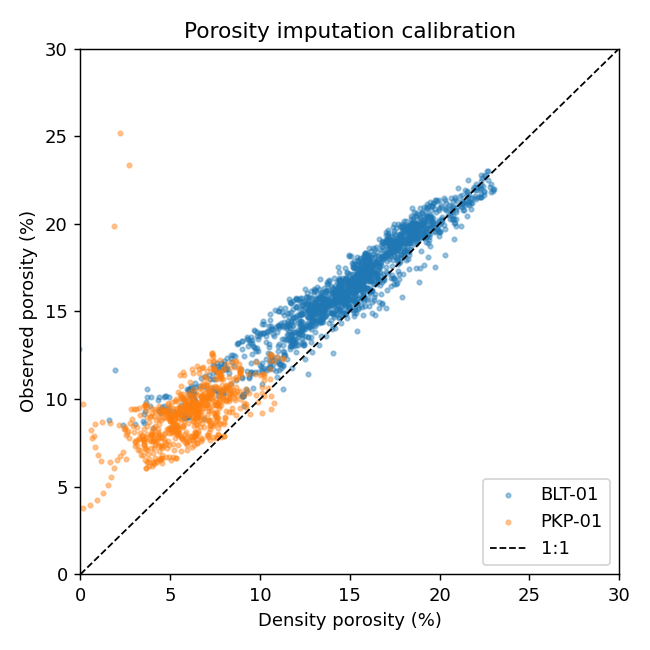

In [6]:
print("\n" + "=" * 78)
print("SECTION 3 — POROSITY IMPUTATION (density porosity, calibrated)")
print("=" * 78)
print("Per-well density-porosity vs measured (where measured exists):")
for well, m in porosity_log_quality().items():
    print(f"  {well}: corr={m['corr']:.2f}  R²(raw)={m['r2_raw']:+.2f}  (n={int(m['n'])})")
print("\nLeave-one-well-out is pessimistic with only two cored wells of unequal quality:")
for well, m in porosity_cross_well_skill().items():
    print(f"  predict {well}: R²={m['r2']:+.2f}  RMSE={m['rmse']:.2f} %")
print("\nOut-of-sample check vs independent ThermoGIS regional porosity:")
check = imputed_vs_thermogis(clean)
for _, r in check.iterrows():
    print(
        f"  {r['well']}: pipeline {r['porosity_pipeline']:5.1f}%  vs ThermoGIS "
        f"{r['porosity_thermogis']:5.1f}%  (Δ {r['difference']:+.1f}, {r['source']})"
    )

# Crossplot: density porosity vs observed, on the wells that have measured porosity.
obs = clean[clean["porosity_source"] == "observed"]
phi_d = density_porosity(np.asarray(obs["log_rhob"], dtype=float)) * 100.0
fig, ax = plt.subplots(figsize=(5, 5))
for wid, g in obs.groupby("well_id"):
    pd_g = density_porosity(np.asarray(g["log_rhob"], dtype=float)) * 100.0
    ax.scatter(pd_g, g["porosity_obs"], s=6, alpha=0.4, label=str(wid))
lims = [0, 30]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Density porosity (%)")
ax.set_ylabel("Observed porosity (%)")
ax.set_title("Porosity imputation calibration")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
fig.tight_layout()
fig.savefig(FIG_DIR / "porosity_calibration.png", dpi=130)

from IPython.display import Image as _Image
_Image(str(FIG_DIR / "porosity_calibration.png"))

## Section 4: Reservoir summary and depth profiles

Finally we pull the cleaned numbers together per well: true-vertical top and net thickness, average porosity and **permeability** (how easily fluid flows through the rock, in millidarcies), temperature, and an indicative power estimate. The four panels plot porosity against true depth for each well — blue where porosity was measured, orange where we imputed it — so you can see the filled wells behave like the measured ones.


SECTION 4 — PORO-PERM TREND + RESERVOIR SUMMARY
well      TVD top  net TVD  poro%  perm mD   T°C  P50 MW
BLT-01       1862      122   16.4    173.3    77     5.1
EVD-01       1783       77   11.7     23.5    72     0.0
JUT-01       1655      126   13.7     67.8    72     2.3
PKP-01       2207       64    9.0     12.9    88     0.0

Figures written to /Users/vadmin/Documents/Lab/Projects/DSEATS/June26GeoDatathon/outputs/figures/phase1
Clean dataset cached to /Users/vadmin/Documents/Lab/Projects/DSEATS/June26GeoDatathon/outputs/clean_reservoir.parquet


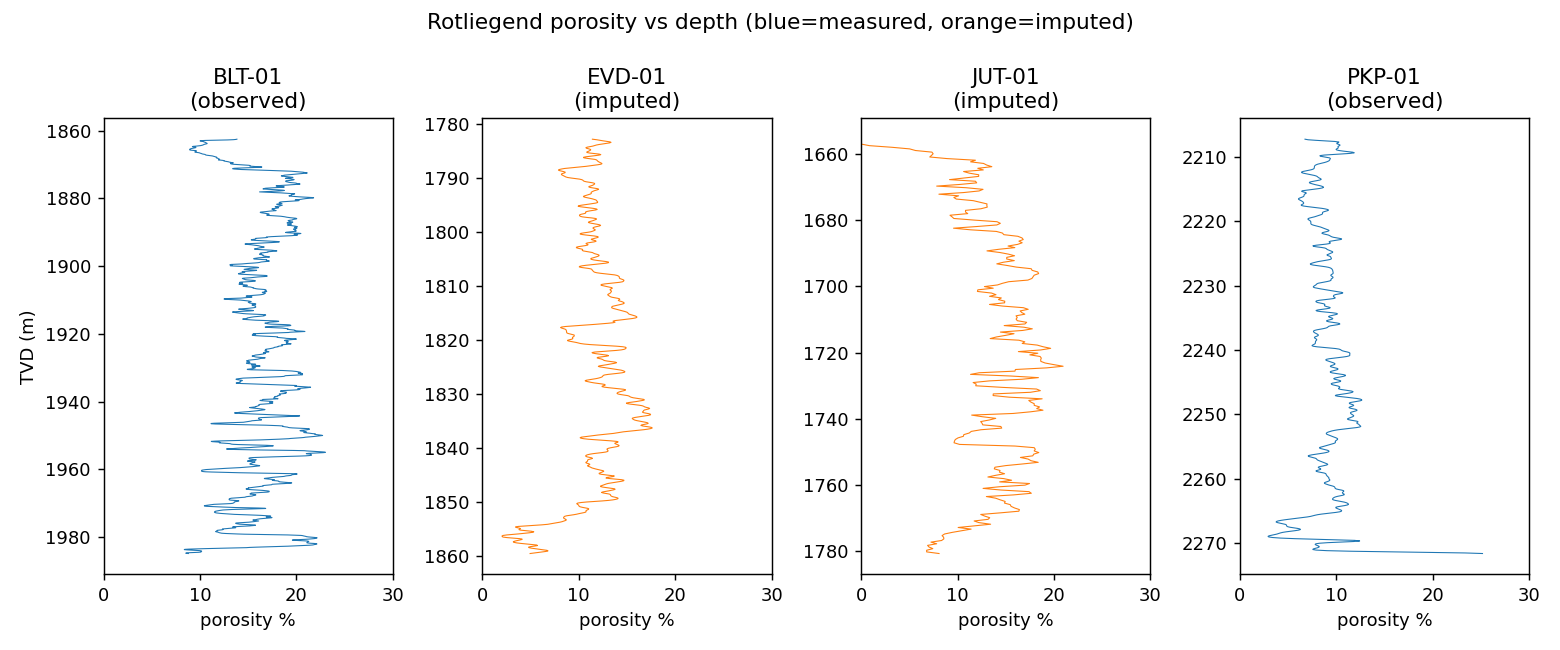

In [7]:
print("\n" + "=" * 78)
print("SECTION 4 — PORO-PERM TREND + RESERVOIR SUMMARY")
print("=" * 78)
header = f"{'well':8s}{'TVD top':>9s}{'net TVD':>9s}{'poro%':>7s}{'perm mD':>9s}{'T°C':>6s}{'P50 MW':>8s}"
print(header)
for wid, g in clean.groupby("well_id"):
    print(
        f"{wid:8s}{g['formation_top_tvd_m'].iloc[0]:9.0f}{g['formation_thickness_tvd_m'].iloc[0]:9.0f}"
        f"{g['porosity_final'].mean():7.1f}{g['permeability_md'].mean():9.1f}"
        f"{thermogis[wid].value('Temperature'):6.0f}{thermogis[wid].value('Power'):8.1f}"
    )

# Porosity-depth profiles per well (observed vs imputed).
fig, axes = plt.subplots(1, 4, figsize=(12, 5), sharey=False)
for ax, wid in zip(axes, config.WELL_IDS, strict=True):
    g = clean[clean["well_id"] == wid].sort_values("depth_tvd_m")
    color = "tab:blue" if g["porosity_source"].iloc[0] == "observed" else "tab:orange"
    ax.plot(g["porosity_final"], g["depth_tvd_m"], color=color, lw=0.6)
    ax.invert_yaxis()
    ax.set_title(f"{wid}\n({g['porosity_source'].iloc[0]})")
    ax.set_xlabel("porosity %")
    ax.set_xlim(0, 30)
axes[0].set_ylabel("TVD (m)")
fig.suptitle("Rotliegend porosity vs depth (blue=measured, orange=imputed)")
fig.tight_layout()
fig.savefig(FIG_DIR / "porosity_profiles.png", dpi=130)

print(f"\nFigures written to {FIG_DIR}")
print(f"Clean dataset cached to {config.OUTPUTS_DIR / 'clean_reservoir.parquet'}")

from IPython.display import Image as _Image
_Image(str(FIG_DIR / "porosity_profiles.png"))